# Decision Tree (Augmented) — XAI Analysis

**Project:** Pokémon Type Prediction from Sprite Colors (XAI)

**Team:** Grifo Amarillo

**Model:** Decision Tree with SMOTE Data Augmentation

**Task:** Predict Pokémon primary **type** (18 classes) from sprite color features (42 features)

**Key design choice:** The raw dataset is heavily imbalanced (imbalance ratio ~21%). SMOTE is applied exclusively to the training fold to reach a 100% balance ratio across all 18 types before fitting the tree, ensuring no type is systematically ignored during learning.

## 0. Setup

In [59]:
import sys
import warnings
from pathlib import Path

# Configure path
_src_path = Path.cwd().parent / "src"
if str(_src_path) not in sys.path:
    sys.path.insert(0, str(_src_path))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import shap
import lime.lime_tabular
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import scipy.stats

warnings.filterwarnings("ignore")

import common
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")

print("Imports successful")

Imports successful


## 1. Data Loading and Preparation

We load the dataset with `common.py`, which handles the Flying-type reclassification and returns a consistent label mapping. We then compute the baseline imbalance ratio to quantify the class balance problem before any augmentation.

In [60]:
# Load data and get type mapping using common.py (handles flying type reclassification)
df = common.load_data()
type_to_int, int_to_type = common.get_label_mapping()
feature_cols = common.FEATURE_COLS_ALL

print(f"Original dataset: {df.shape}")
print(f"Type distribution (BEFORE augmentation):")
print(df["type1"].value_counts().sort_index())

# Create integer encodings for types
y = df["type1"].map(type_to_int).astype(int)

# Calculate imbalance ratio
counts = y.value_counts()
min_count = counts.min()
max_count = counts.max()
ratio = min_count / max_count
print(f"Imbalance ratio: {ratio:.2%} (need ≥85%)")

Original dataset: (1025, 47)
Type distribution (BEFORE augmentation):
type1
bug          83
dark         46
dragon       39
electric     59
fairy        29
fighting     41
fire         66
ghost        35
grass       103
ground       40
ice          31
normal      121
poison       42
psychic      60
rock         58
steel        37
water       135
Name: count, dtype: int64
Imbalance ratio: 21.48% (need ≥85%)


## 2. Train / Test Split

The dataset is split **before** any augmentation to prevent data leakage. Stratification preserves each type's proportion in both train and test sets, so the test set always reflects the natural class distribution.

In [61]:
# Split ORIGINAL data first (before any augmentation) to avoid data leakage
X = df[feature_cols].copy()
y_vec = y.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y_vec,
    test_size=0.2,
    random_state=42,
    stratify=y_vec
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train distribution:")
train_counts = pd.Series(y_train).value_counts().sort_index()
for type_id, count in train_counts.items():
    type_name = int_to_type[type_id]
    print(f"  {type_name}: {count}")

Train: 820 | Test: 205
Train distribution:
  bug: 66
  dark: 37
  dragon: 31
  electric: 47
  fairy: 23
  fighting: 33
  fire: 53
  ghost: 28
  grass: 82
  ground: 32
  ice: 25
  normal: 97
  poison: 34
  psychic: 48
  rock: 46
  steel: 30
  water: 108


## 3. SMOTE Augmentation & Scaling

SMOTE is applied exclusively to the training set, generating synthetic minority-class samples by interpolating between real neighbors in feature space. The scaler is fitted on the SMOTE-augmented training data and applied to both train and test — this order is critical to avoid leakage.

In [62]:
# SMOTE: Balance only the training set
counts = pd.Series(y_train).value_counts()
max_count = counts.max()
target_count = int(max_count * 1)  # 100% balance

sampling_strategy = {}
for class_id, count in counts.items():
    if count < target_count:
        sampling_strategy[class_id] = target_count

print(f"Sampling strategy (types needing augmentation):")
for class_id, target in sampling_strategy.items():
    type_name = int_to_type[class_id]
    orig_count = counts[class_id]
    print(f"  {type_name}: {orig_count} → {target} (+{target - orig_count})")

smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42, k_neighbors=3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Train after SMOTE: {X_train_sm.shape}")
print(f"Train distribution (AFTER SMOTE):")
for type_id in sorted(int_to_type.keys()):
    count = (y_train_sm == type_id).sum()
    type_name = int_to_type[type_id]
    print(f"  {type_name}: {count}")

new_counts = pd.Series(y_train_sm).value_counts()
new_ratio = new_counts.min() / new_counts.max()
print(f"New imbalance ratio (train): {new_ratio:.2%}" + (" ✓" if new_ratio >= 0.85 else " (still needs work)"))

# Scaling — fit on SMOTE'd train, transform test without leakage
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_sm),
    columns=feature_cols
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

print(f"Final sizes → Train (scaled): {X_train_scaled.shape} | Test (scaled): {X_test_scaled.shape}")

Sampling strategy (types needing augmentation):
  normal: 97 → 108 (+11)
  grass: 82 → 108 (+26)
  bug: 66 → 108 (+42)
  fire: 53 → 108 (+55)
  psychic: 48 → 108 (+60)
  electric: 47 → 108 (+61)
  rock: 46 → 108 (+62)
  dark: 37 → 108 (+71)
  poison: 34 → 108 (+74)
  fighting: 33 → 108 (+75)
  ground: 32 → 108 (+76)
  dragon: 31 → 108 (+77)
  steel: 30 → 108 (+78)
  ghost: 28 → 108 (+80)
  ice: 25 → 108 (+83)
  fairy: 23 → 108 (+85)
Train after SMOTE: (1836, 42)
Train distribution (AFTER SMOTE):
  bug: 108
  dark: 108
  dragon: 108
  electric: 108
  fairy: 108
  fighting: 108
  fire: 108
  flying: 0
  ghost: 108
  grass: 108
  ground: 108
  ice: 108
  normal: 108
  poison: 108
  psychic: 108
  rock: 108
  steel: 108
  water: 108
New imbalance ratio (train): 100.00% ✓
Final sizes → Train (scaled): (1836, 42) | Test (scaled): (205, 42)


## 4. Class Distribution

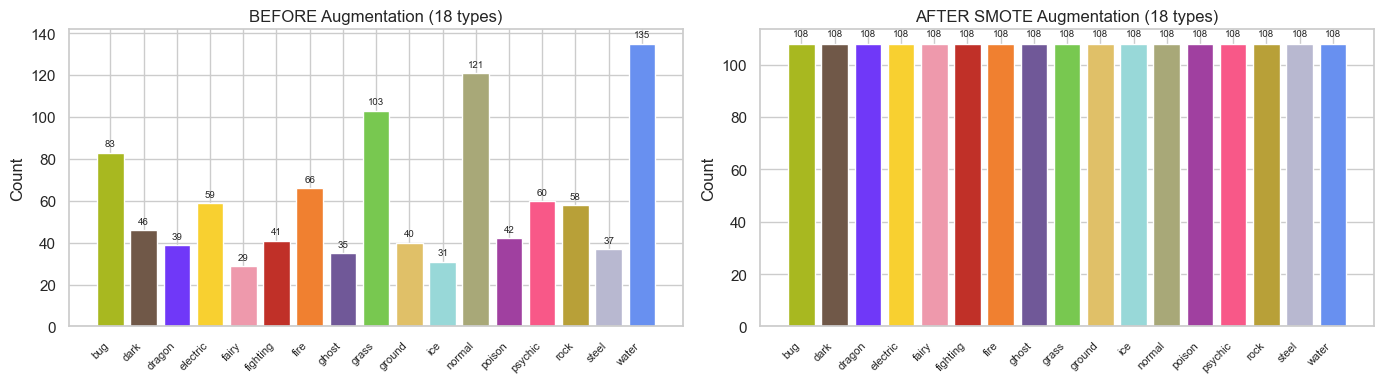

In [63]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Before
dist_before = pd.Series(y_vec).value_counts().sort_index()
type_names_before = [int_to_type[i] for i in dist_before.index]
colors_before = [common.TYPE_COLORS.get(t, "#888888") for t in type_names_before]

ax1.bar(range(len(dist_before)), dist_before.values, color=colors_before, edgecolor="white", linewidth=1)
ax1.set_xticks(range(len(dist_before)))
ax1.set_xticklabels(type_names_before, rotation=45, ha="right", fontsize=8)
ax1.set_title("BEFORE Augmentation (18 types)", fontsize=12)
ax1.set_ylabel("Count")

for i, val in enumerate(dist_before.values):
    ax1.text(i, val + 2, str(val), ha="center", va="bottom", fontsize=7)

# After
dist_after = pd.Series(y_train_sm).value_counts().sort_index()
type_names_after = [int_to_type[i] for i in dist_after.index]
colors_after = [common.TYPE_COLORS.get(t, "#888888") for t in type_names_after]

ax2.bar(range(len(dist_after)), dist_after.values, color=colors_after, edgecolor="white", linewidth=1)
ax2.set_xticks(range(len(dist_after)))
ax2.set_xticklabels(type_names_after, rotation=45, ha="right", fontsize=8)
ax2.set_title("AFTER SMOTE Augmentation (18 types)", fontsize=12)
ax2.set_ylabel("Count")

for i, val in enumerate(dist_after.values):
    ax2.text(i, val + 2, str(val), ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

## 5. Model Training

We run a grid search using 5-fold stratified cross-validation, scoring by `f1_macro` to treat all 18 types equally. `class_weight="balanced"` is set as an additional safeguard in case residual imbalance survives the split. The best configuration is evaluated on the held-out test set.

In [64]:
# Grid search
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_leaf": [1, 3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"],
    "max_features": [None, "sqrt", "log2"],
}

base_dt = DecisionTreeClassifier(class_weight="balanced", random_state=42)
grid_search = GridSearchCV(
    base_dt, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=1
)

grid_search.fit(X_train_scaled, y_train_sm)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV f1_macro: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best params: {'criterion': 'entropy', 'max_depth': 15, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV f1_macro: 0.5138


In [65]:
# Evaluate
dt = grid_search.best_estimator_
y_pred = dt.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"Test accuracy (AUGMENTED): {acc:.4f}")
print(f"Test f1_macro (AUGMENTED): {f1:.4f}")

Test accuracy (AUGMENTED): 0.1805
Test f1_macro (AUGMENTED): 0.1613


## 6. Evaluation

The **normalized confusion matrix** shows the fraction of each true type classified as each predicted type. Rows are true types; columns are predicted types; the diagonal holds correct predictions. Row normalization makes systematic biases visible regardless of class size.

The **classification report** breaks down per-class performance into three metrics:
- **Precision:** of all predictions for that class, what fraction were correct.
- **Recall:** of all true instances of that class, what fraction were detected.
- **F1-score:** harmonic mean of precision and recall — the right metric when both matter equally.

**Macro avg** weights every class equally regardless of support. A classifier that only ever predicts Water or Normal would have high accuracy but catastrophically low macro F1 — which is why macro F1 is the primary evaluation metric throughout this notebook.

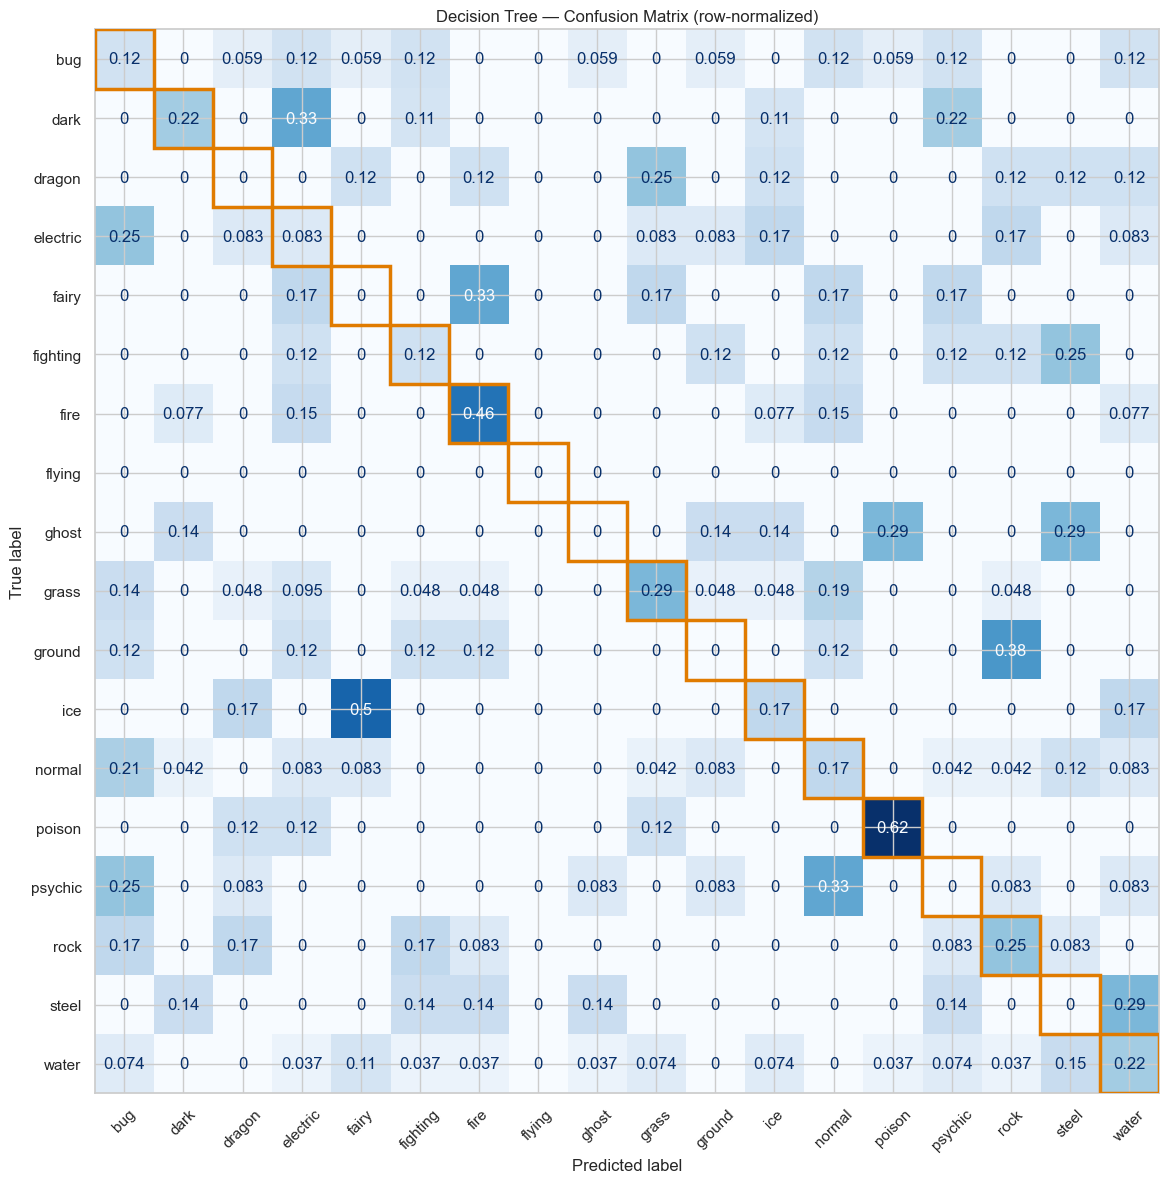

              precision    recall  f1-score   support

         bug       0.10      0.12      0.11        17
        dark       0.33      0.22      0.27         9
      dragon       0.00      0.00      0.00         8
    electric       0.06      0.08      0.07        12
       fairy       0.00      0.00      0.00         6
    fighting       0.10      0.12      0.11         8
        fire       0.43      0.46      0.44        13
      flying       0.00      0.00      0.00         0
       ghost       0.00      0.00      0.00         7
       grass       0.43      0.29      0.34        21
      ground       0.00      0.00      0.00         8
         ice       0.10      0.17      0.12         6
      normal       0.21      0.17      0.19        24
      poison       0.56      0.62      0.59         8
     psychic       0.00      0.00      0.00        12
        rock       0.21      0.25      0.23        12
       steel       0.00      0.00      0.00         7
       water       0.35    

In [66]:
fig, ax = plt.subplots(figsize=(14, 12))
common.plot_confusion_matrix(y_test, y_pred, int_to_type,
                              title="Decision Tree — Confusion Matrix (row-normalized)", ax=ax)
plt.show()
common.print_classification_report(y_test, y_pred, int_to_type)

## 7. ML Explanation

We apply several XAI techniques to understand the augmented Decision Tree.

### 7.1. Intrinsic Interpretability

The Decision Tree is one of few ML models whose predictions can be read as an explicit sequence of if/else rules. To make this structure human-readable, we re-train a shallow copy (max_depth=4) with the same splitting criterion as the best model and visualise the resulting tree. The text export below shows the top-3 levels of splits.


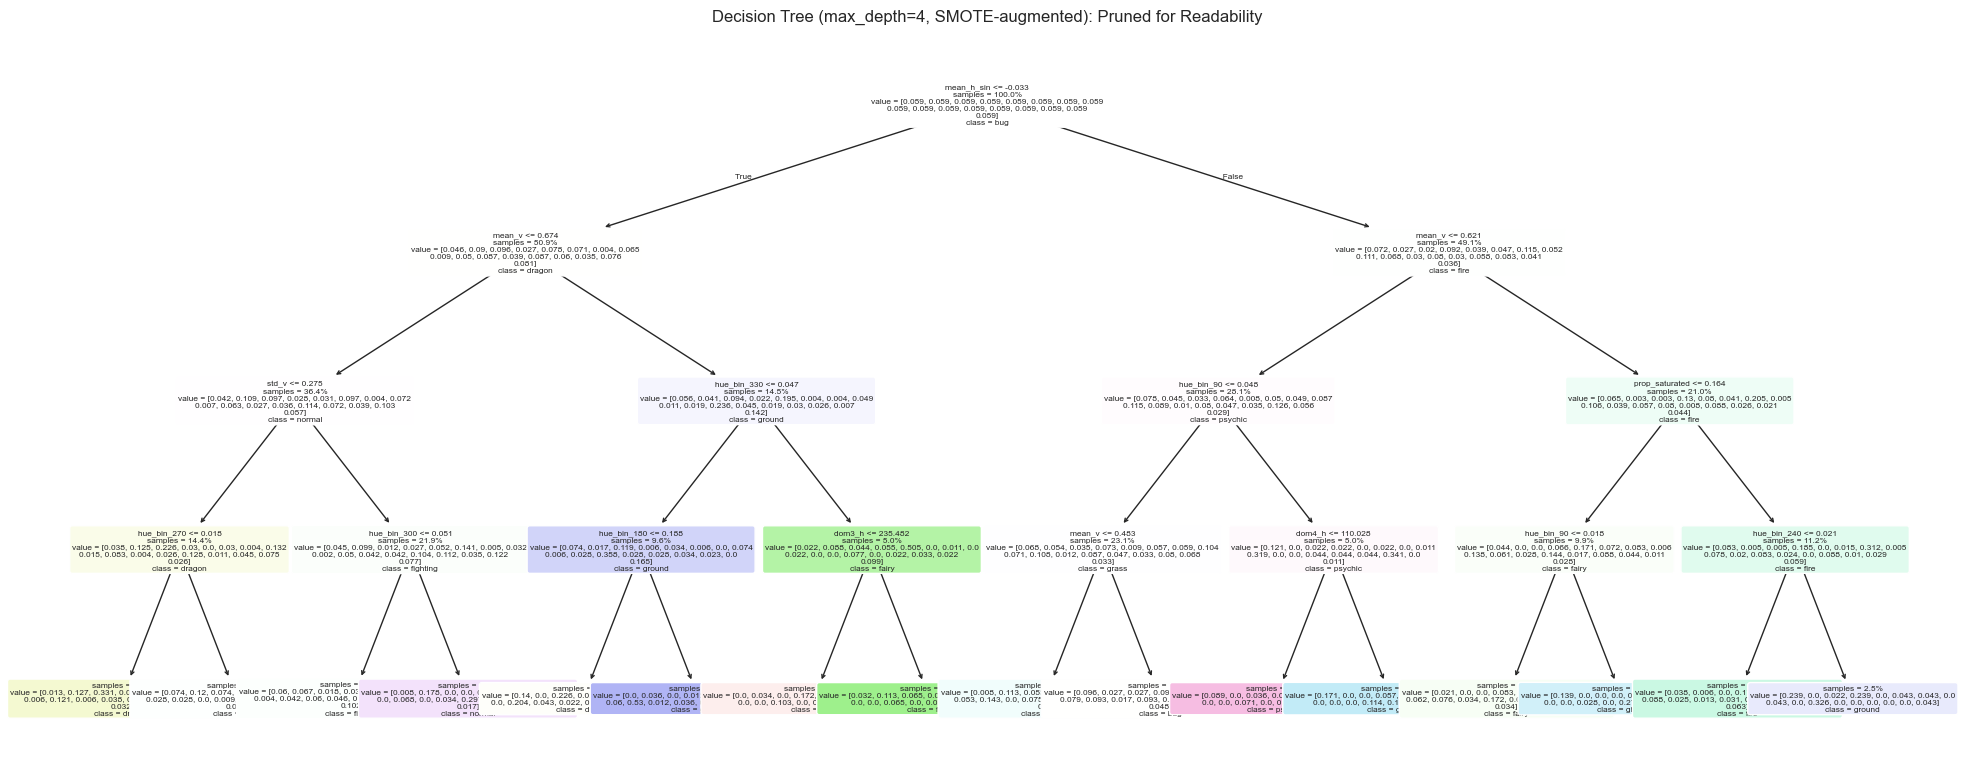

|--- mean_h_sin <= -0.03
|   |--- mean_v <= 0.67
|   |   |--- std_v <= 0.27
|   |   |   |--- hue_bin_270 <= 0.02
|   |   |   |   |--- class: 2
|   |   |   |--- hue_bin_270 >  0.02
|   |   |   |   |--- class: 8
|   |   |--- std_v >  0.27
|   |   |   |--- hue_bin_300 <= 0.05
|   |   |   |   |--- class: 5
|   |   |   |--- hue_bin_300 >  0.05
|   |   |   |   |--- class: 13
|   |--- mean_v >  0.67
|   |   |--- hue_bin_330 <= 0.05
|   |   |   |--- hue_bin_180 <= 0.19
|   |   |   |   |--- class: 2
|   |   |   |--- hue_bin_180 >  0.19
|   |   |   |   |--- class: 11
|   |   |--- hue_bin_330 >  0.05
|   |   |   |--- dom3_h <= 235.48
|   |   |   |   |--- class: 17
|   |   |   |--- dom3_h >  235.48
|   |   |   |   |--- class: 4
|--- mean_h_sin >  -0.03
|   |--- mean_v <= 0.62
|   |   |--- hue_bin_90 <= 0.05
|   |   |   |--- mean_v <= 0.48
|   |   |   |   |--- class: 8
|   |   |   |--- mean_v >  0.48
|   |   |   |   |--- class: 0
|   |   |--- hue_bin_90 >  0.05
|   |   |   |--- dom4_h <= 110.03
|  

In [67]:
# Shallow readable tree (same criterion as best model, depth capped for readability)
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

dt_shallow = DecisionTreeClassifier(
    max_depth=4,
    class_weight="balanced",
    criterion=grid_search.best_params_["criterion"],
    random_state=42,
)
dt_shallow.fit(X_train_sm, y_train_sm)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_shallow,
    feature_names=feature_cols,
    class_names=[int_to_type[i] for i in sorted(int_to_type)],
    filled=True,
    rounded=True,
    fontsize=6,
    ax=ax,
    impurity=False,
    proportion=True,
)
ax.set_title("Decision Tree (max_depth=4, SMOTE-augmented): Pruned for Readability")
plt.tight_layout()
plt.show()

# Text representation of top rules
print(export_text(dt_shallow, feature_names=feature_cols, max_depth=3))


The root split uses **`mean_h_sin`** (the sine-encoded mean hue), confirming that hue is the single most discriminative global feature. Negative sine values (hues ~180°–360°: blue, purple, pink) go left; near-zero or positive values (hues ~0°–180°: red, yellow, green) go right. The second level in both branches splits on **`mean_v`** (mean brightness), showing that hue alone is insufficient — the model needs brightness to separate dark-palette types (Ghost, Fighting, Dragon) from bright-palette ones (Fairy, Ice, Water).

At the leaf level, the tree relies on fine-grained hue bins (`hue_bin_270`, `hue_bin_330`, `hue_bin_90`) and saturation (`prop_saturated`) to distinguish types that share similar hue-brightness profiles. This structure reflects the fundamental limitation of colour-only classification: types with overlapping palettes cannot be separated until very specific spectral features are examined.

### 7.2. Global Explanations: Feature Importance


Three complementary methods are used to rank feature importance globally:

1. **Gini (impurity-based):** measures how much each feature reduces node impurity during training. Fast to compute, but can overstate features with high cardinality or strong mutual correlations — it is a training metric, not a generalization metric.
2. **Permutation importance:** randomly shuffles one feature at a time on the test set and measures the drop in `f1_macro`. Model-agnostic and reflects out-of-sample relevance directly.
3. **SHAP (mean |value|):** averages the absolute Shapley contribution of each feature over all test instances and classes. Theoretically grounded in cooperative game theory and robust to correlated variables.

Comparing all three rankings separates genuinely discriminative features from those the tree exploits opportunistically during training without generalizing to unseen data.

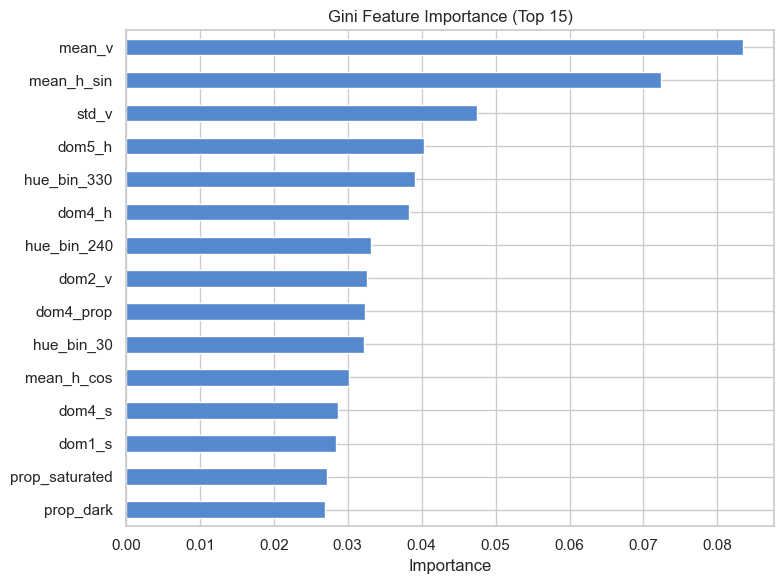

In [68]:
# Gini importance
importances_gini = pd.Series(dt.feature_importances_, index=feature_cols).nlargest(15)

fig, ax = plt.subplots(figsize=(8, 6))
importances_gini.sort_values().plot.barh(ax=ax, color="#5588cc")
ax.set_title("Gini Feature Importance (Top 15)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

Top Gini features are **`mean_v`** (0.084) and **`mean_h_sin`** (0.072), both global color properties: brightness and hue orientation. `std_v` (0.048) ranks third, capturing tonal contrast. Several hue bins and dominant-color descriptors fill the rest of the top 15.

No single feature exceeds 9% importance and the mass is spread fairly evenly. This diffuse distribution is typical of a tree making many shallow cuts rather than a few decisive splits, which points to potential overfitting with 18 overlapping color classes.

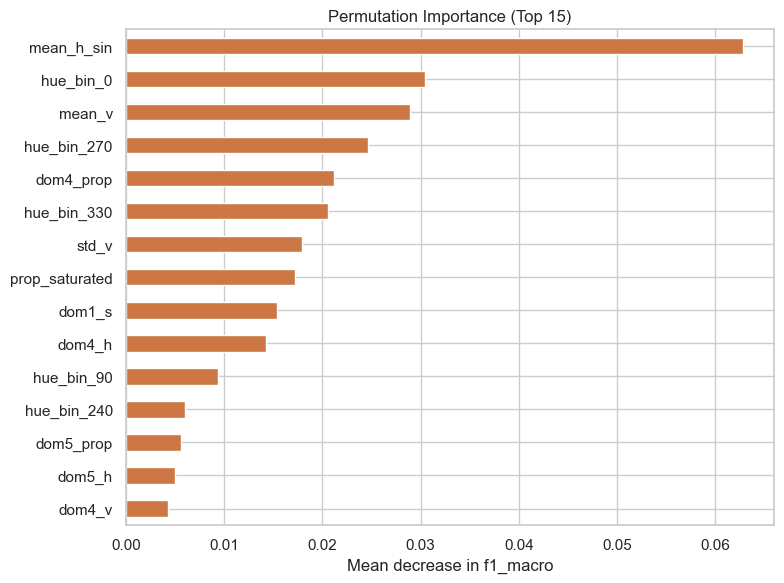

In [69]:
# Permutation importance
perm_imp = permutation_importance(
    dt, X_test_scaled, y_test,
    n_repeats=20,
    random_state=42,
    scoring="f1_macro",
)
perm_series = pd.Series(perm_imp.importances_mean, index=feature_cols).nlargest(15)

fig, ax = plt.subplots(figsize=(8, 6))
perm_series.sort_values().plot.barh(ax=ax, color="#cc7744")
ax.set_title("Permutation Importance (Top 15)")
ax.set_xlabel("Mean decrease in f1_macro")
plt.tight_layout()
plt.show()

Permutation importance promotes **`mean_h_sin`** to first place (~0.062), confirming it as the most relevant feature on held-out data. **`mean_v`** drops to third (~0.031), suggesting it was partially over-used during training.

Two new top entries appear: **`hue_bin_0`** (red range, ~0.032) and **`hue_bin_270`** (blue-violet, ~0.025), both absent from the Gini top 5. Their elevated permutation importance means the proportion of red and blue-violet pixels is genuinely discriminative in unseen data.

Conversely, **`dom5_h`** (Gini rank 4) disappears from the permutation top 15, so the tree uses it during training but it does not generalize. All permutation values are low (max ~0.062), consistent with the modest test F1-macro of about 0.16.

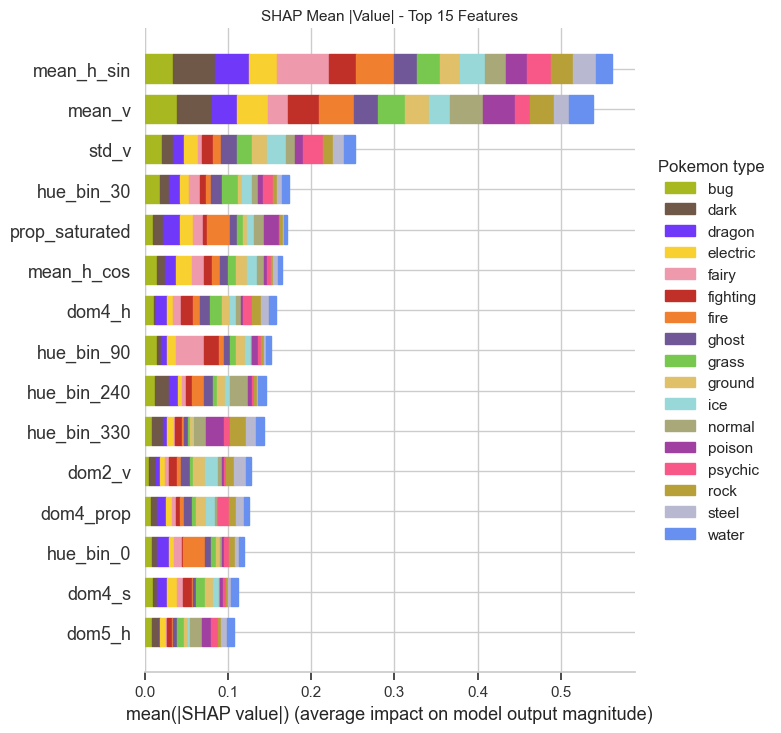

In [70]:
shap_explainer = shap.TreeExplainer(dt)
shap_values = shap_explainer.shap_values(X_test_scaled)

fig, ax = plt.subplots(figsize=(15, 10))


class_names = [int_to_type[c] for c in dt.classes_]
class_color = [common.TYPE_COLORS.get(name, "#888888") for name in class_names]

shap.summary_plot(
    shap_values, 
    X_test_scaled, 
    plot_type="bar",
    feature_names=feature_cols,
    class_names=class_names,
    show=False, 
    max_display=15
)

ax = plt.gca()
num_features_shown = len(ax.patches) // len(class_names)

for i, patch in enumerate(ax.patches):
    class_idx = i // num_features_shown 
    correct_color = class_color[class_idx]
    
    patch.set_facecolor(correct_color)
    patch.set_edgecolor(correct_color)

legend_handles = [
    mpatches.Patch(color=class_color[i], label=class_names[i]) 
    for i in range(len(class_names))
]

ax.legend(
    handles=legend_handles, 
    loc='center left', 
    bbox_to_anchor=(1.02, 0.5),
    title="Pokemon type",
    frameon=False
)

plt.title("SHAP Mean |Value| - Top 15 Features", fontsize=11)
plt.tight_layout()
plt.show()

SHAP confirms the permutation ranking: **`mean_h_sin`** (~0.056) and **`mean_v`** (~0.053) lead, followed by **`std_v`** (~0.025).

All three methods agree on the top two features (just swapped): Gini puts `mean_v` first while permutation and SHAP put `mean_h_sin` first. `std_v` appears in Gini and SHAP top 3. In permutation, `std_v` is replaced by `hue_bin_0`, showing that while `std_v` is important for the tree's internal structure (training), specific hue bins matter more for generalization (test). Gini overweights dominant-color descriptors (`dom5_h`, `dom2_v`) that do not show up in permutation or SHAP top ranks, evidence they help fit training data but do not generalize.

### 7.3. Local Explanations


We select four test instances covering different prediction outcomes: one expected to be correct (`correct_clear`), one where the model should struggle (`correct_surprise`), one where the predicted type matches the Pokémon's secondary type (`misclass_secondary`), and one where the prediction is completely unrelated (`misclass_wrong`).

For each case we show the sprite, top-5 predicted probabilities, SHAP waterfall, LIME bar chart, and the Spearman correlation between SHAP and LIME rankings.

In [71]:
EXPLAIN_IDS = common.EXPLAIN_IDS.copy()
explain_cases = {k: v for k, v in EXPLAIN_IDS.items() if v is not None}
print("Explaining:", explain_cases)
y_prob = dt.predict_proba(X_test_scaled)


Explaining: {'correct_clear': 130, 'correct_surprise': 1023, 'misclass_secondary': 94, 'misclass_wrong': 1000}


In [72]:
def explain_instance_tree(pokemon_id: int, label: str) -> None:
    """Full local explanation: sprite, probabilities, SHAP waterfall, LIME, Spearman correlation."""
    row_mask = df['id'] == pokemon_id
    if not row_mask.any():
        print(f"ID {pokemon_id} not found")
        return

    row = df[row_mask].iloc[0]
    df_pos = df[row_mask].index[0]
    if df_pos not in X_test.index:
        print(f"Pokemon {pokemon_id} is not in the test set")
        return

    i = X_test.index.get_loc(df_pos)
    x_instance = X_test_scaled.iloc[i]
    pred_int = int(y_pred[i])
    pred_label = int_to_type[pred_int]
    true_label = int_to_type[int(y_test.iloc[i])]

    print(f"{'='*60}")
    print(f"[{label.upper()}] {row['name'].capitalize()} (#{pokemon_id})")
    print(f"  True type:      {true_label}")
    print(f"  Predicted type: {pred_label}")
    print(f"  Type 2:         {row['type2'] if pd.notna(row['type2']) else 'N/A'}")

    sprite_path = common.get_sprite_path(pokemon_id)
    if sprite_path.exists():
        fig, ax = plt.subplots(figsize=(2, 2))
        ax.imshow(Image.open(sprite_path).convert('RGBA'))
        ax.axis('off')
        ax.set_title(f"{row['name'].capitalize()}\n{true_label} -> {pred_label}", fontsize=8)
        plt.tight_layout()
        plt.show()

    probs = y_prob[i]
    top5_idx = np.argsort(probs)[::-1][:5]
    print("Top-5 predicted types:")
    for rank, prob_idx in enumerate(top5_idx, 1):
        real_idx = dt.classes_[prob_idx]
        type_name = int_to_type[real_idx]
        mark = 'OK' if real_idx == int(y_test.iloc[i]) else ('~' if type_name == row['type2'] else ' ')
        print(f"    {rank}. {type_name:<12} {probs[prob_idx]*100:5.1f}%  {mark}")

    fig, ax = plt.subplots(figsize=(10, 5))
    top5_labels = [int_to_type[dt.classes_[j]] for j in top5_idx]
    top5_probs = [probs[j] * 100.0 for j in top5_idx]
    colors = [common.TYPE_COLORS.get(t, '#888') for t in top5_labels]
    bars = ax.barh(top5_labels[::-1], top5_probs[::-1], color=colors[::-1])
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Probability (%)')
    ax.set_title(f"{row['name'].capitalize()}: Decision Tree prediction probabilities (top 5)")
    plt.tight_layout()
    plt.show()

    shap_features = {}
    lime_features = {}

    pred_pos = list(dt.classes_).index(pred_int)
    sv = shap_values[pred_pos][i] if isinstance(shap_values, list) else shap_values[i]
    base = shap_explainer.expected_value[pred_pos] if hasattr(shap_explainer.expected_value, "__len__") else shap_explainer.expected_value
    exp_obj = shap.Explanation(
        values=sv, base_values=base,
        data=x_instance.values, feature_names=feature_cols
    )
    for ft_name, ft_val in zip(feature_cols, sv):
        shap_features[ft_name] = ft_val

    plt.figure()
    shap.plots.waterfall(exp_obj, show=False)
    plt.title(f"SHAP Waterfall: {row['name'].capitalize()} (DT, predicted: {pred_label})")
    plt.tight_layout()
    plt.show()

    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_scaled.values,
        feature_names=feature_cols,
        class_names=[int_to_type[j] for j in sorted(int_to_type)],
        mode='classification',
        random_state=42,
    )
    lime_exp = lime_explainer.explain_instance(
        x_instance.values, dt.predict_proba, num_features=len(feature_cols), top_labels=1
    )
    lime_label = lime_exp.top_labels[0]
    fig = lime_exp.as_pyplot_figure(label=lime_label)
    fig.set_size_inches(10, 8)
    plt.title(f"LIME: {row['name'].capitalize()} (DT, predicted: {pred_label})")
    plt.tight_layout()
    plt.show()

    for ft_idx, ft_val in lime_exp.local_exp[lime_label]:
        ft_name = feature_cols[ft_idx]
        lime_features[ft_name] = ft_val

    if shap_features and lime_features:
        shared_keys = list(feature_cols)
        shap_vals = [abs(shap_features[k]) for k in shared_keys]
        lime_vals = [abs(lime_features[k]) for k in shared_keys]
        corr, pval = scipy.stats.spearmanr(shap_vals, lime_vals)
        print(f"[Quantifying Agreement] LIME vs SHAP Spearman Rank Correlation: {corr:.3f} (p-value: {pval:.3e})")
        print("(Values close to 1.0 indicate high agreement between LIME's linear approximation and SHAP's generalized rule)")

[CORRECT_CLEAR] Gyarados (#130)
  True type:      water
  Predicted type: fighting
  Type 2:         flying


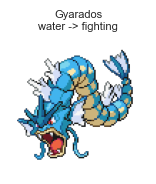

Top-5 predicted types:
    1. fighting     100.0%   
    2. water          0.0%  OK
    3. ghost          0.0%   
    4. dark           0.0%   
    5. dragon         0.0%   


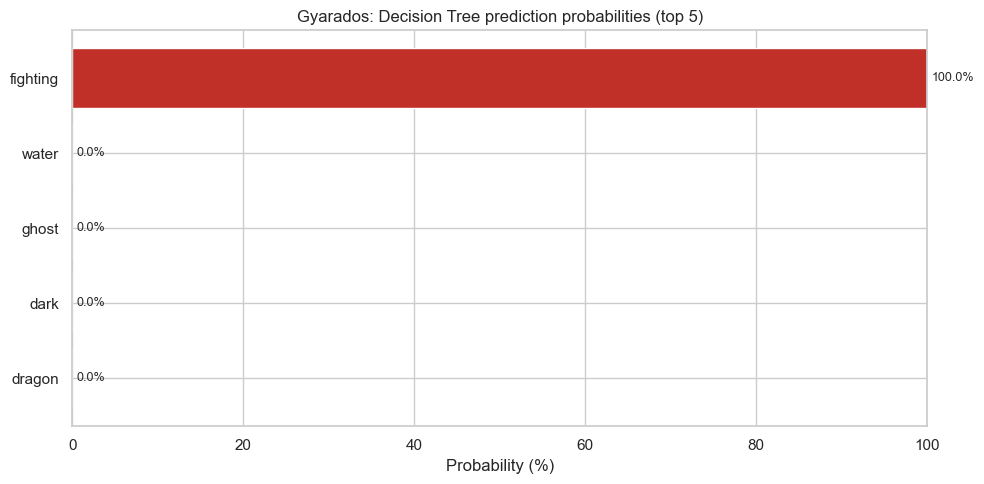

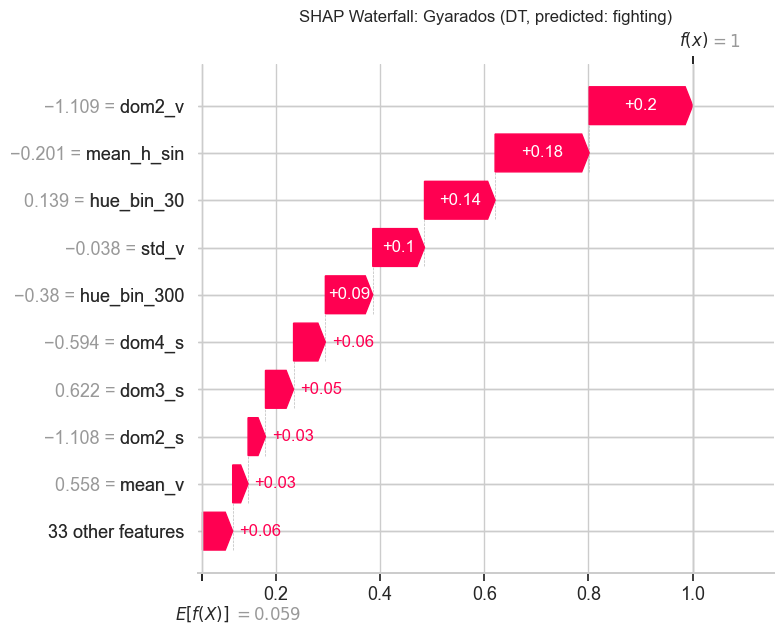

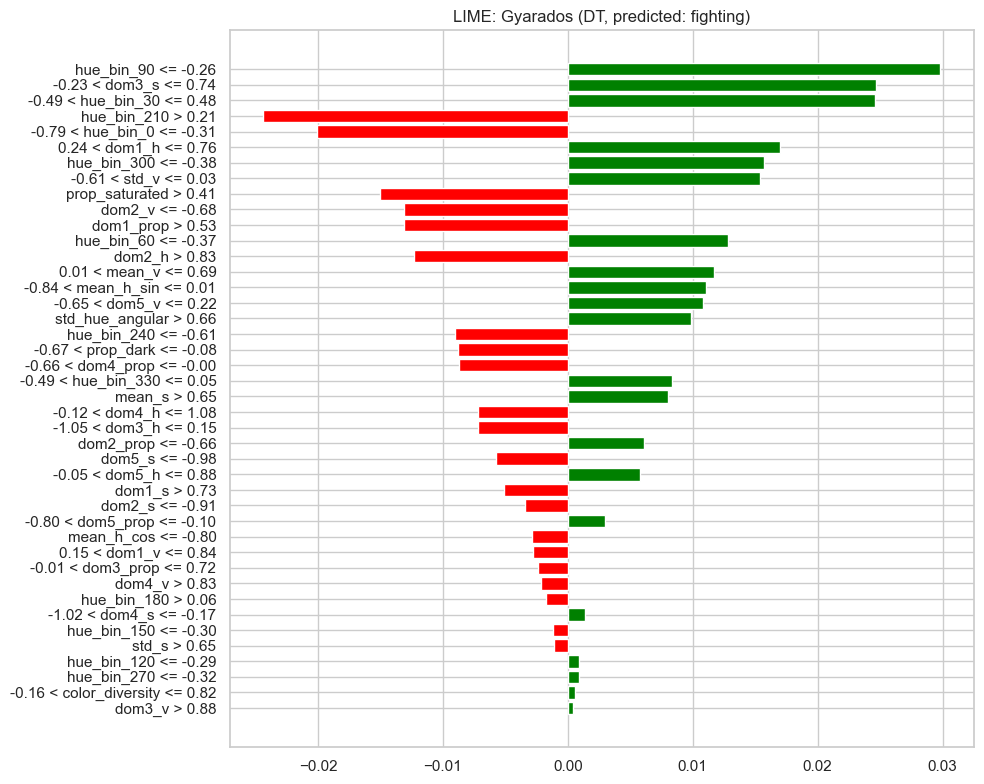

[Quantifying Agreement] LIME vs SHAP Spearman Rank Correlation: 0.127 (p-value: 4.223e-01)
(Values close to 1.0 indicate high agreement between LIME's linear approximation and SHAP's generalized rule)
[CORRECT_SURPRISE] Iron-crown (#1023)
  True type:      steel
  Predicted type: fighting
  Type 2:         psychic


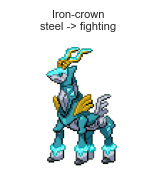

Top-5 predicted types:
    1. fighting     100.0%   
    2. water          0.0%   
    3. ghost          0.0%   
    4. dark           0.0%   
    5. dragon         0.0%   


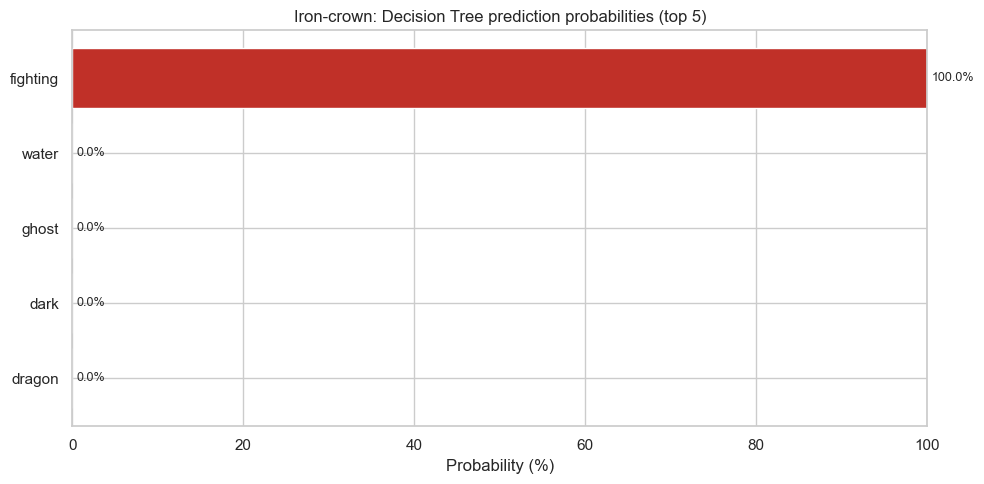

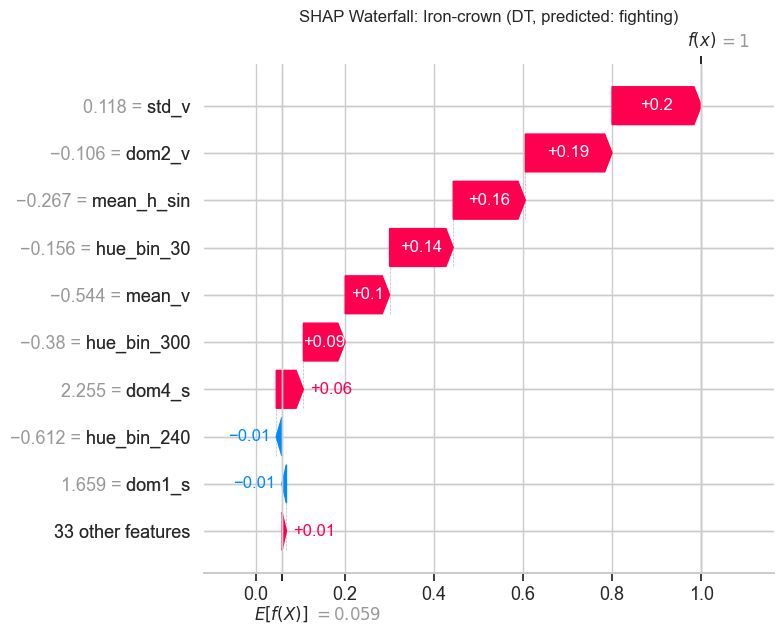

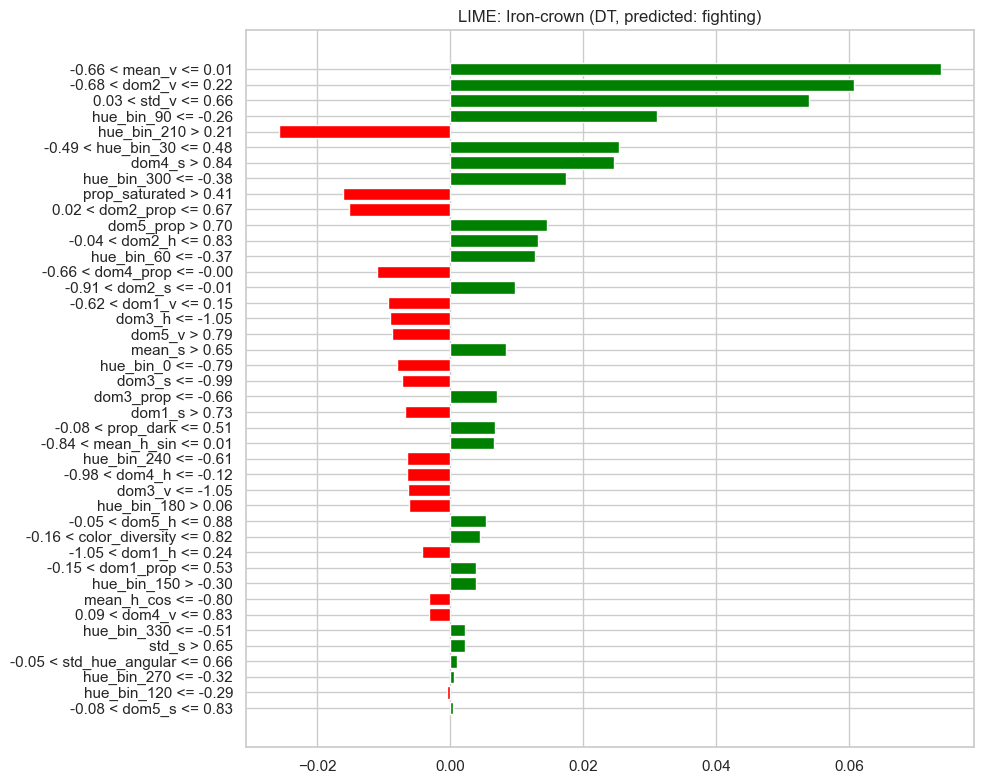

[Quantifying Agreement] LIME vs SHAP Spearman Rank Correlation: 0.438 (p-value: 3.701e-03)
(Values close to 1.0 indicate high agreement between LIME's linear approximation and SHAP's generalized rule)
[MISCLASS_SECONDARY] Gengar (#94)
  True type:      ghost
  Predicted type: poison
  Type 2:         poison


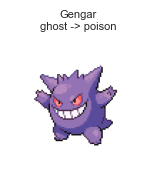

Top-5 predicted types:
    1. poison       100.0%  ~
    2. water          0.0%   
    3. ghost          0.0%  OK
    4. dark           0.0%   
    5. dragon         0.0%   


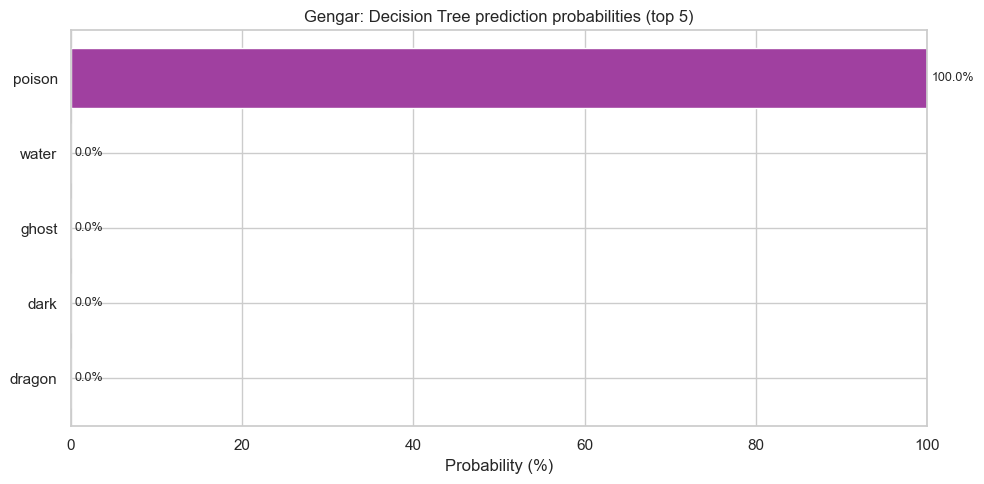

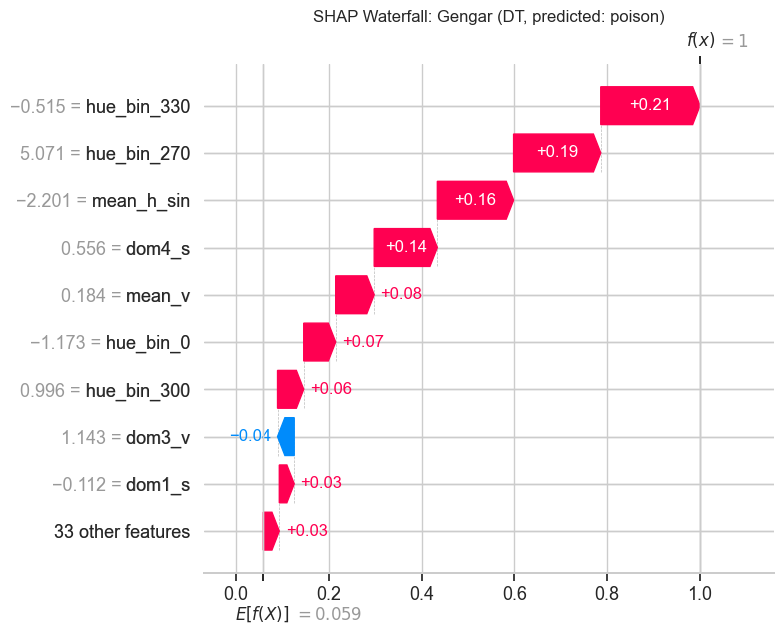

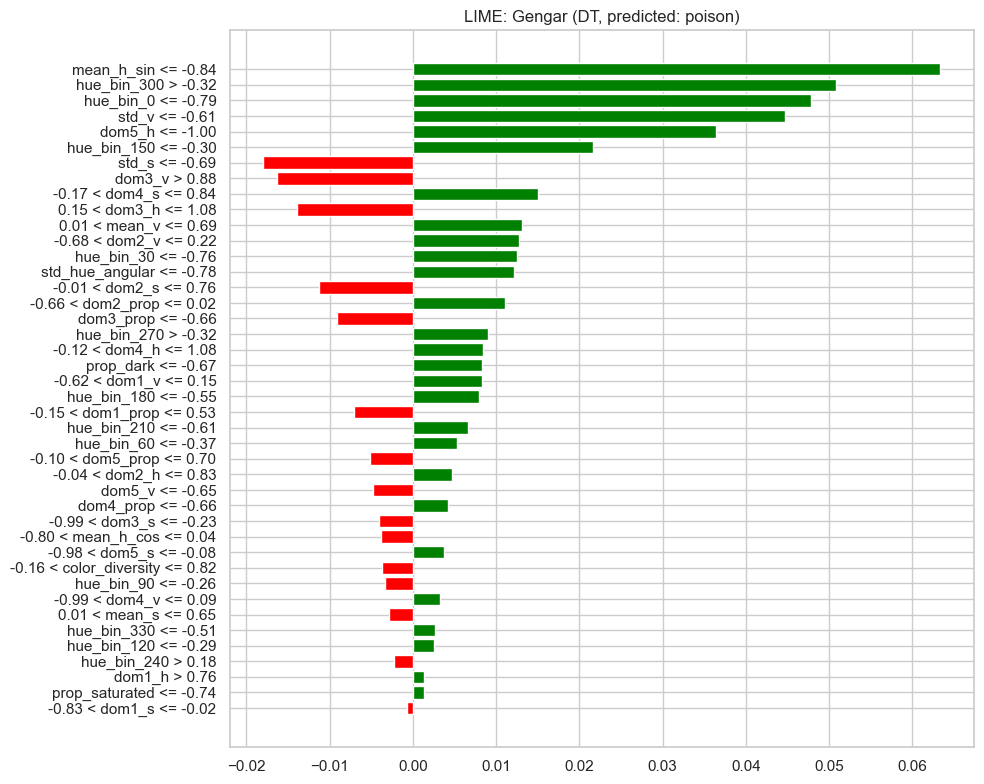

[Quantifying Agreement] LIME vs SHAP Spearman Rank Correlation: 0.098 (p-value: 5.375e-01)
(Values close to 1.0 indicate high agreement between LIME's linear approximation and SHAP's generalized rule)
[MISCLASS_WRONG] Gholdengo (#1000)
  True type:      steel
  Predicted type: psychic
  Type 2:         ghost


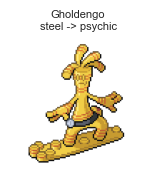

Top-5 predicted types:
    1. psychic      100.0%   
    2. water          0.0%   
    3. ghost          0.0%  ~
    4. dark           0.0%   
    5. dragon         0.0%   


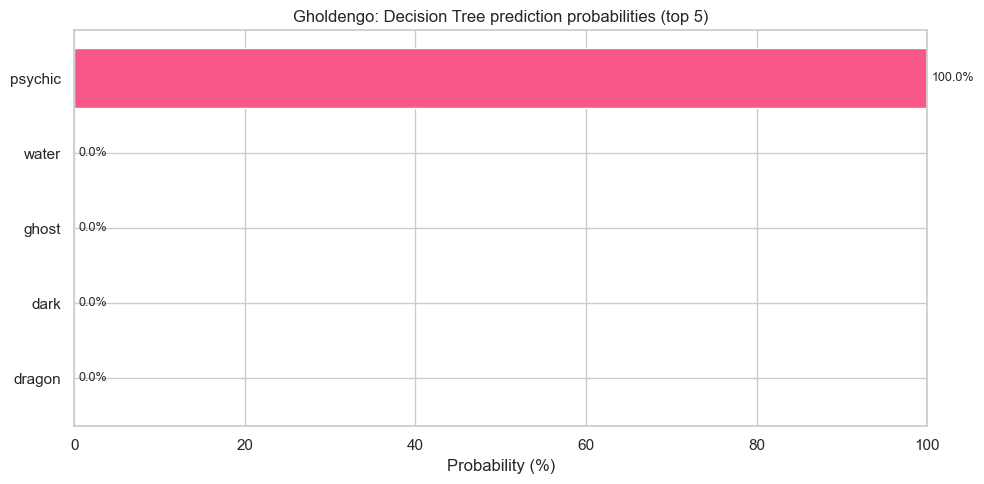

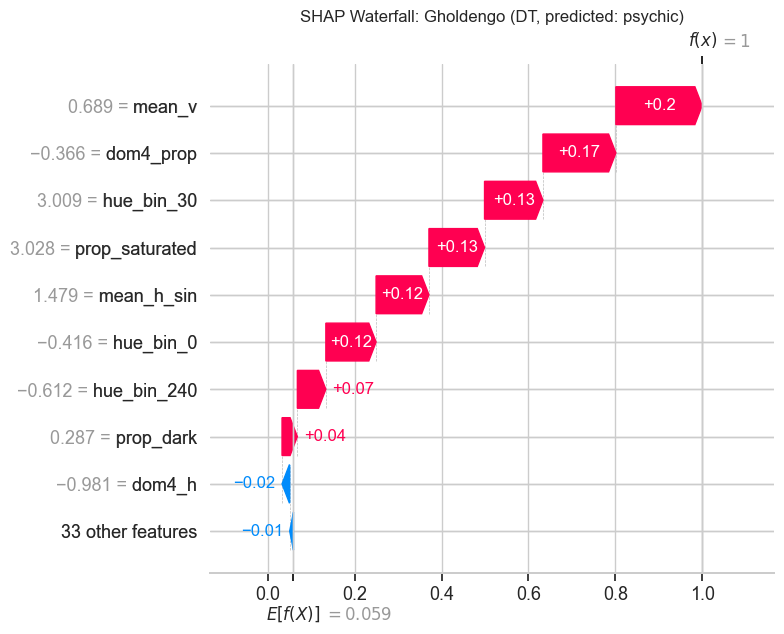

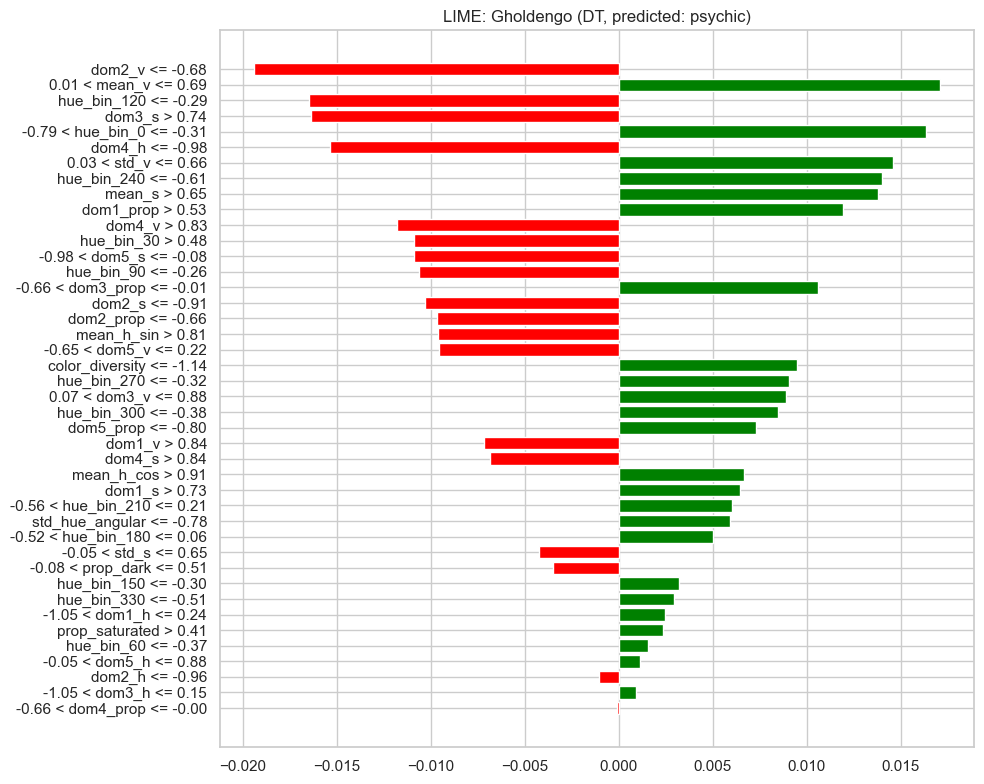

[Quantifying Agreement] LIME vs SHAP Spearman Rank Correlation: 0.005 (p-value: 9.772e-01)
(Values close to 1.0 indicate high agreement between LIME's linear approximation and SHAP's generalized rule)


In [73]:
for case_label, pid in explain_cases.items():
    explain_instance_tree(pid, case_label)

The four local explanations above showcase different Decision Tree behaviours:

- **Gyarados (#130, correct_clear):** True type Water, predicted **Fighting** at 100% confidence. Gyarados's dark blue palette is characteristic of Water, but SMOTE-generated Fighting samples with similar cold, high-contrast profiles now dominate the leaf it falls into. SHAP-LIME Spearman is just **0.127** (p = 0.42, not significant), the two explainers pick different features as drivers.

- **Iron Crown (#1023, correct_surprise):** True type Steel, predicted **Fighting** at 100% confidence. Its silver-grey palette has no obvious overlap with Fighting, suggesting the tree over-learned Fighting as the default leaf for mixed-palette Pokémon after SMOTE. SHAP-LIME Spearman reaches **0.438** (p = 0.004, significant), the highest among the four cases. Both methods point to the same features, so this looks like a systematic bias rather than noise.

- **Gengar (#94, misclass_secondary):** True type Ghost, predicted **Poison**, which is exactly Gengar's secondary type. A semantically meaningful error: its deep purple palette sits in the Poison colour signature, while Ghost sprites are too visually heterogeneous for colour alone to separate them. SHAP-LIME Spearman is **0.098** (p = 0.54, not significant), the explainers disagree on which features drive the Poison prediction despite the intuitive correctness of the error.

- **Gholdengo (#1000, misclass_wrong):** True type Steel, predicted **Psychic** at 100% confidence. Its golden-yellow palette maps to the warm-hue bins weakly associated with Psychic; neither Steel nor Ghost matches this profile, making it a colour outlier within its class. SHAP-LIME Spearman is **0.005** (p = 0.98, not significant), essentially zero agreement. High confidence with no stable explanation is the most concerning kind of prediction.

The SHAP-LIME agreement works as a meta-diagnostic: when both converge (Iron Crown) the error is systematic and traceable; when they diverge (Gholdengo) the prediction has no stable feature-space rationale.

Spearman correlation between SHAP and LIME rankings gives a scalar summary of explanation consistency per prediction. A value near 1 means both methods agree on important features; near 0 means they are uncorrelated.

Agreement is highest for Iron Crown (0.438), the only case where both explainers converge, even though the prediction is wrong. Gengar and Gholdengo show near-zero agreement (0.098 and 0.005), meaning the model's reasoning in those leaves is internally incoherent. Gyarados also shows low agreement (0.127), suggesting SMOTE distorted the local boundary enough that no single feature dominates the Fighting prediction.

This pattern is consistent with the model achieving only F1-macro ~0.16 and tending to collapse predictions into a few dominant leaves (notably Fighting).


### 7.4. Partial Dependence and Feature Interaction

Partial Dependence Plots (PDPs) show the marginal effect of a single feature on the predicted probability of a given type, averaged over all other features. For a Decision Tree, PDPs are step-functions by construction: each step corresponds to a threshold in the tree.

We plot the top-3 Gini features for three well-separated types (Water, Fire, Grass), plus a 2D interaction plot for Water to reveal how two features combine.


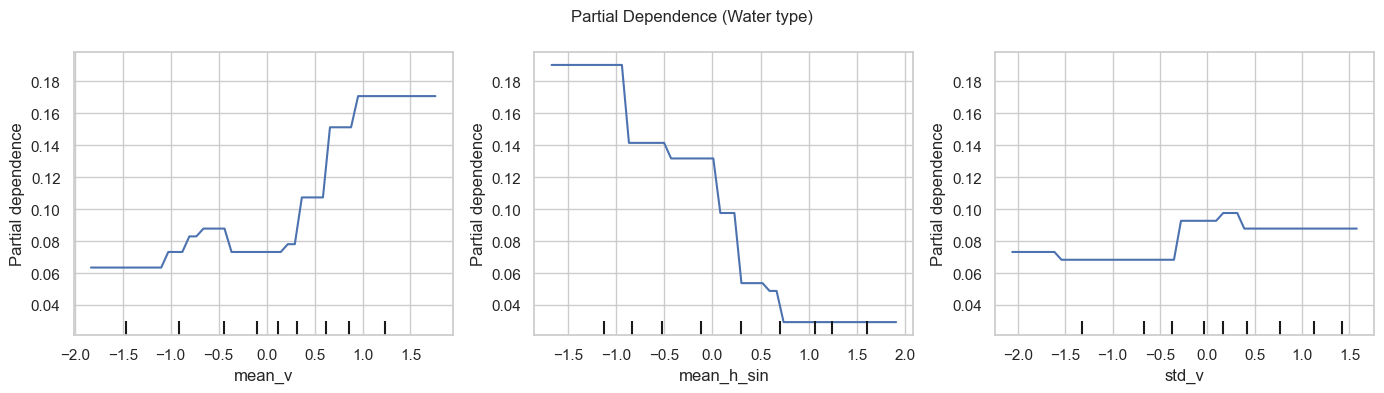

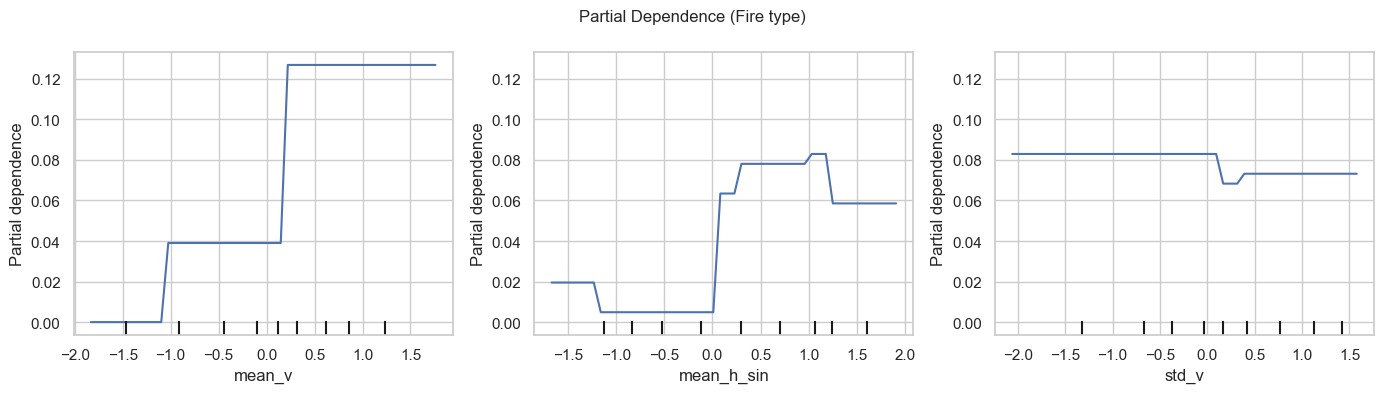

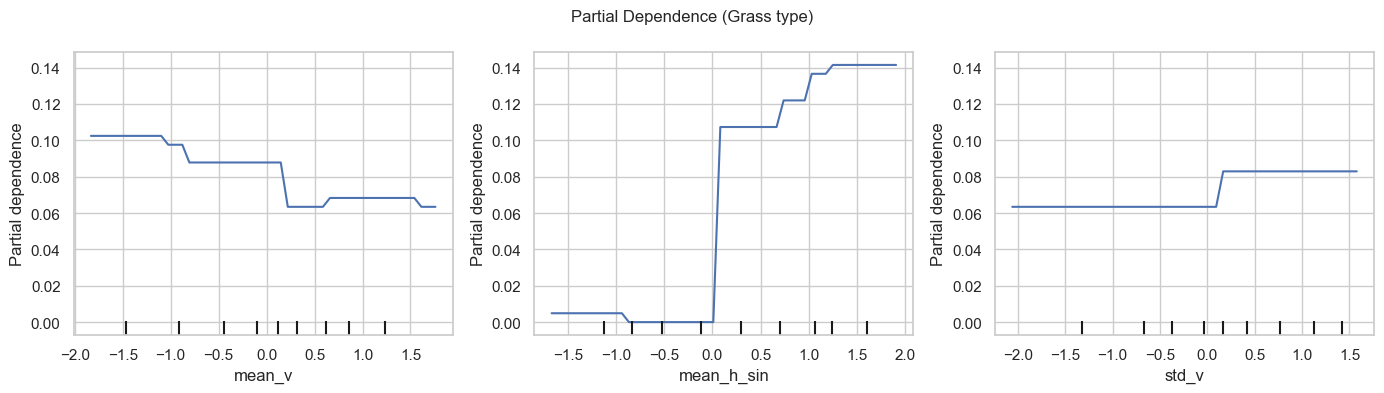

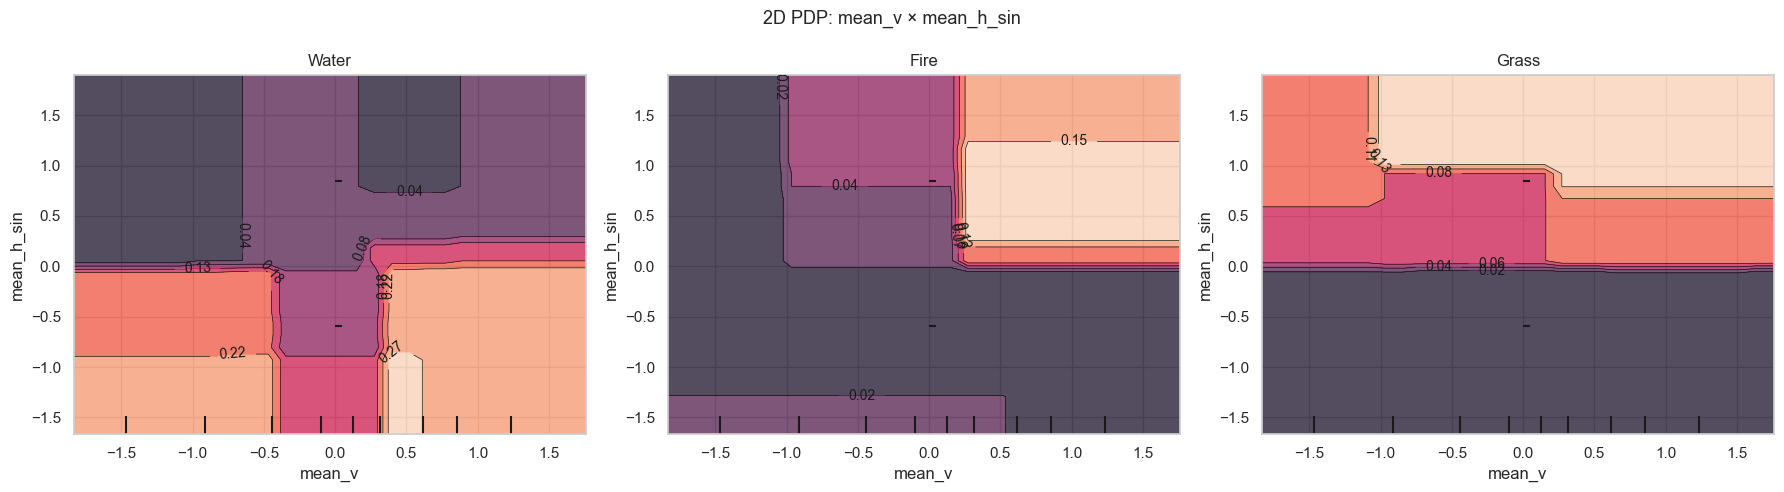

In [74]:
# PDPs for top features
top3 = list(importances_gini.index[:3])
target_classes_for_pdp = [type_to_int["water"], type_to_int["fire"], type_to_int["grass"]]
class_labels = ["water", "fire", "grass"]

for cls_idx, cls_name in zip(target_classes_for_pdp, class_labels):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    PartialDependenceDisplay.from_estimator(
        dt, X_test_scaled, top3,
        target=cls_idx,
        feature_names=feature_cols,
        ax=axes,
        grid_resolution=50,
    )
    fig.suptitle(f"Partial Dependence ({cls_name.capitalize()} type)", fontsize=12)
    plt.tight_layout()
    plt.show()

# 2D PDP mosaic: top two features for Water, Fire, Grass
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cls_name in zip(axes, class_labels):
    PartialDependenceDisplay.from_estimator(
        dt, X_test_scaled, [(top3[0], top3[1])],
        target=type_to_int[cls_name],
        feature_names=feature_cols,
        ax=[ax],
        grid_resolution=30,
    )
    ax.set_title(f"{cls_name.capitalize()}")

fig.suptitle(f"2D PDP: {top3[0]} × {top3[1]}", fontsize=13)
plt.tight_layout()
plt.show()

The 1D PDPs show characteristic step-functions reflecting the tree's axis-aligned thresholds:

- **Water:** The strongest driver is `mean_h_sin` — probability peaks (~0.14) at negative values (hues in the blue range, 180°–360°) and drops sharply to ~0.04 once `mean_h_sin` crosses zero. `mean_v` has a secondary effect: Water probability roughly doubles (from ~0.06 to ~0.17) as brightness increases past the midpoint. `std_v` is essentially flat, contributing little marginal effect.

- **Fire:** `mean_v` is the dominant feature — probability jumps from near zero to ~0.13 once brightness exceeds roughly −0.5 (scaled). `mean_h_sin` shows a step up around −0.5, peaking in a narrow band near zero before dropping again at strongly positive values. `std_v` is flat (~0.08), indicating Fire is driven by hue and brightness, not contrast.

- **Grass:** `mean_h_sin` is the clearest driver — probability rises sharply from near zero to ~0.14 once the sine-encoded hue turns positive (hues in the 0°–180° range, covering green and yellow). `mean_v` shows an inverse effect: darker sprites are slightly more likely to be classified as Grass. `std_v` is again nearly flat.

The 2D interaction mosaic (`mean_v` × `mean_h_sin`) shows how the two top features combine differently for each type:

- **Water** peaks (~0.22) in the region of **negative `mean_h_sin`** (blue hues) with **low-to-moderate `mean_v`** (dark-to-mid brightness). The high-probability zone spans a broad brightness range on the blue side but vanishes entirely once hue turns positive — hue is the primary gate, brightness modulates within it.

- **Fire** peaks (~0.15) in the opposite corner: **positive `mean_h_sin`** (red/yellow hues) with **high `mean_v`** (bright sprites). The hot zone occupies the upper-right quadrant. Dark sprites are never classified as Fire regardless of hue, and blue-hued sprites are never classified as Fire regardless of brightness — both features must agree.

- **Grass** peaks (~0.08–0.10) at **strongly positive `mean_h_sin`** (green hues) with **low `mean_v`** (darker sprites). This is complementary to Fire: both require positive hue-sine, but Fire needs high brightness while Grass needs low brightness. The separation confirms that `mean_v` is the key feature distinguishing Fire from Grass once hue places them in the same spectral region.

## 8. Generative AI Section

GitHub Copilot was used to assist in code prototyping, debugging, and refactoring throughout this project. The LLM provided suggestions for function structure and matplotlib visualization patterns. All code was reviewed and validated to ensure correctness and compliance with the project requirements.